In [1]:
import os, sys
import copy
import pickle
import pandas as pd
import scanpy as sc
import numpy as np

import scipy.stats as stats
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import KMeans

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
matplotlib.rcParams['pdf.fonttype'] = 42 
import importlib
import analysis

# Analysis worksheeet

This worksheet provides the code needed to generate the trajectory figures for the AMPPD project. 

### Load model files

Load the results of model training and inference, saved as h5ad's (performd in process_model_output.ipynb).  
TODO: specify in the manuscript which version of the AD model we used!

In [17]:
base_dir = "../model_output/processed_model_files"

# pd_model_fn = os.path.join(base_dir, "Myeloid_pd_0225_pathv2_v0.h5ad")
pd_model_fn = os.path.join(base_dir, "PD_myeloid.h5ad")
ad_model_fn = os.path.join(base_dir, "Immune_AD_0310_bd_braak_only.h5ad") # trained on Braak only
ad_model_fn_db = os.path.join(base_dir, "Immune_AD_1222_bd_v4.h5ad") # traine don Braak + Dementia, same model as Capstone

### Load gene names

Gene names for the PD and AD projects are different and loaded separately. 

In [3]:
meta_fn = "../data/PD_myeloid/metadata.pkl"
meta = pickle.load(open(meta_fn, "rb"))
gene_names_pd = meta["var"]["gene_name"][meta["var"]["protein_coding"]]

meta_fn = "../data/AD_immune/metadata.pkl"
meta = pickle.load(open(meta_fn, "rb"))
gene_names_ad = meta["var"]["gene_name"][ meta["var"]["protein_coding"]]

### Accuracy and PLS trajecotry plots

Used in Extended Data Figure 7b-d

In [4]:
data_pd = analysis.process_data(
    model_fn = pd_model_fn, 
    sigma = np.sqrt(0.1), 
    shuffle_braak = False,
    braak_feature_name = "pred_path_braak_lb_condensed",
    zenith_save_fn = "../zenith/PD_myeloid_zenith_input.csv",
    gene_names = gene_names_pd,
)

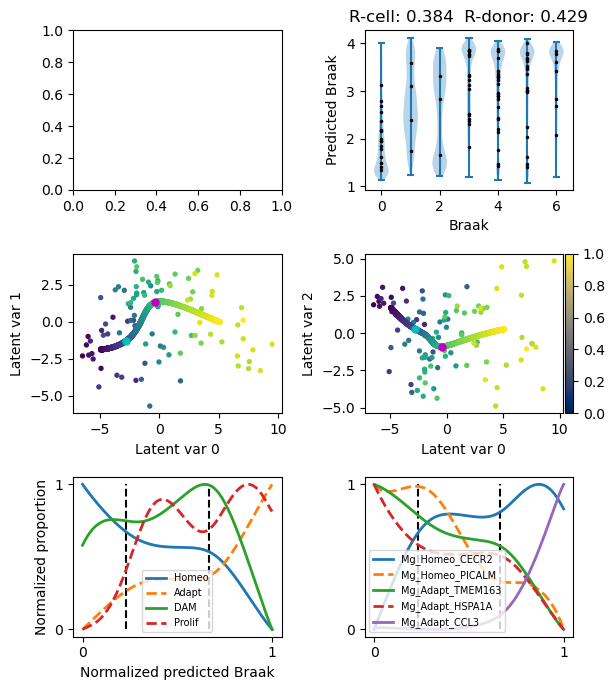

In [6]:
analysis.plot_basics(data_pd, save_fig_fn = None)

In [7]:
# pickle.dump(data, open("myeloid_data_0321.pkl", "wb"))

## PD Hotspot analysis

Figure 7f&g in original manuscript.  
Hotspot gene modules found in Micro_PVM_modules_top1000_removedmin1.csv

In [8]:
hotspot_fn = "../hotspot_modules/Micro_PVM_modules_top1000_removedmin1.csv"
hotspot_df = pd.read_csv(hotspot_fn)

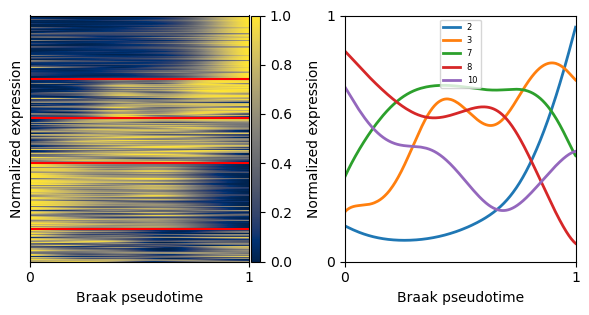

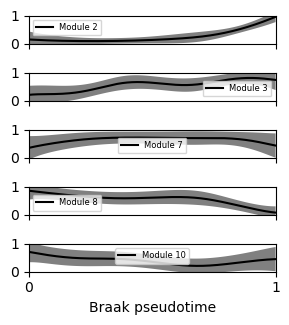

In [9]:
x_pd, y_pd, y_pd_se, clusters_pd = analysis.plot_hotspot_heatmap(
    hotspot_df, 
    gene_names_pd,
    data_pd["braak_filtered"], 
    data_pd["genes_filtered_full"], 
    clusters = [2, 3, 7, 8, 10], # hotspot cluster numbers
    normalized=True,
)

## AD Hotspot analysis

In [10]:
data_ad = analysis.process_data(
    model_fn = ad_model_fn, 
    sigma = np.sqrt(0.1), 
    n_time_pts = 1000, 
    zenith_save_fn = None,
    gene_names = gene_names_ad,
)

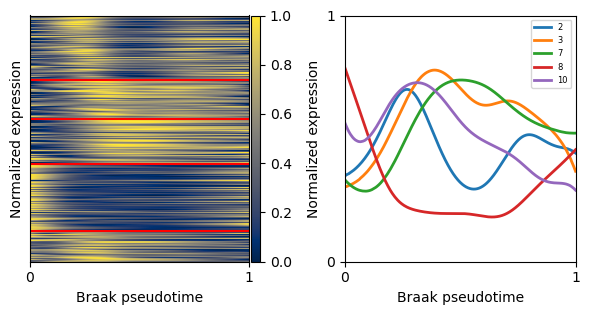

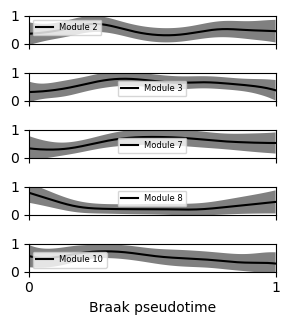

In [11]:
x_ad, y_ad, y_ad_se, clusters_ad = analysis.plot_hotspot_heatmap(
    hotspot_df, 
    gene_names_ad,
    data_ad["braak_filtered"], 
    data_ad["genes_filtered_full"], 
    clusters= [2, 3, 7, 8, 10], 
    normalized = True,
)

### Plot overlap of PD and AD hotspots
Supplementary Figure 12b

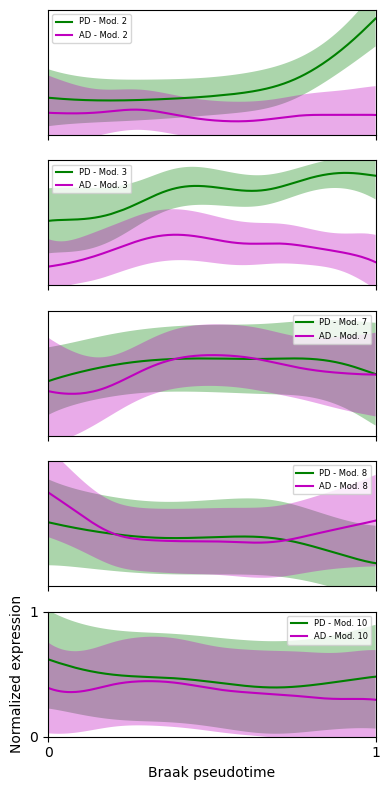

In [12]:
analysis.plot_hotspot_overaly(
    clusters_pd, 
    clusters_ad, 
    x_pd, 
    x_ad, 
    clusters = [2, 3, 7, 8, 10],
    save_fig_fn = None,
)

### Zenith pathway enrichment

The Zenith output files for each sliding window was generated using R_scripts/zenith_loop.R.  
Used for Supplementary Figure 12a.

In [13]:
path_enr = analysis.PathEnrichment("../zenith/zenith_output", FDR_cutoff = 0.0001, n_min_significant_windows = 4)

In [14]:
path_enr.df_filtered.head(5)

,index,go_id,pathway,original_pathway,FDR,direction,delta,ngenes,n_significant
0,0,GO:0042026,protein refolding,GO0042026: protein refolding,1.946544e-44,Up,0.302008,22,22
1,1,GO:0051131,chaperone-mediated protein complex assembly,GO0051131: chaperone-mediated protein complex ...,1.244505e-36,Up,0.261991,19,22
2,2,GO:0061077,chaperone-mediated protein folding,GO0061077: chaperone-mediated protein folding,3.060224e-36,Up,0.176521,68,23
3,3,GO:0090084,negative regulation of inclusion body assembly,GO0090084: negative regulation of inclusion bo...,2.931617e-34,Up,0.382847,11,21
4,4,GO:0051085,chaperone cofactor-dependent protein refolding,GO0051085: chaperone cofactor-dependent protei...,1.240916e-27,Up,0.197831,30,22


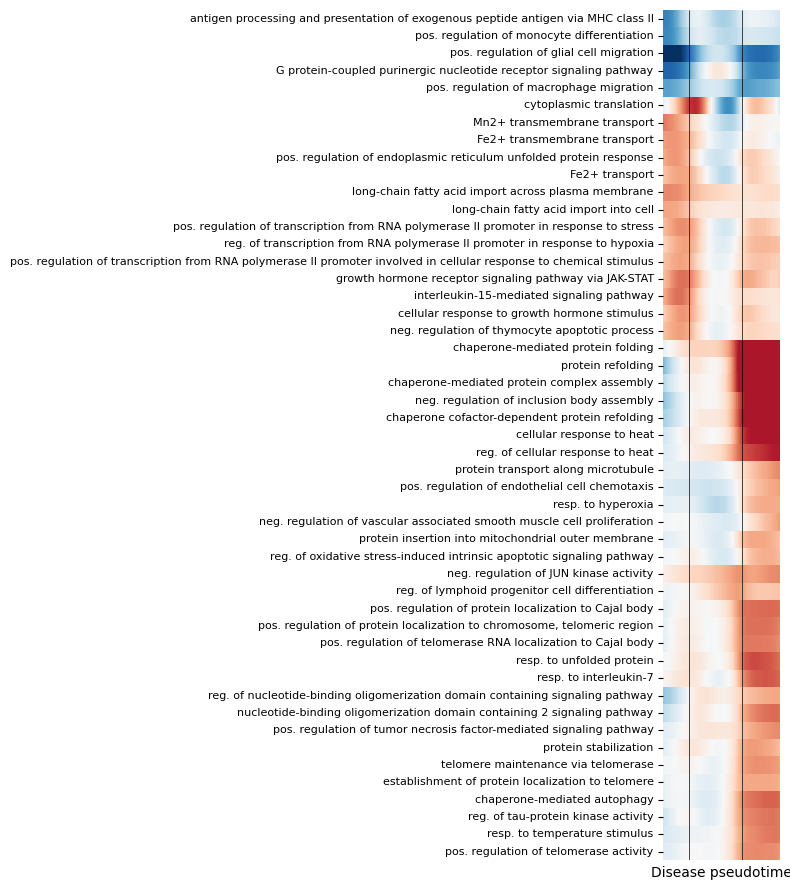

In [15]:
pathways = path_enr.df_filtered.pathway.values
time_pts = data_pd["braak_mid_pts"]
pred_braak_traj = data_pd["braak_filtered"]

transition_pts = data_pd["transitions"] / len(pred_braak_traj)

path_enr.generate_sliding_window_figure(
        pathways,
        time_pts=time_pts,
        pred_braak_traj=pred_braak_traj,
        transition_pts=transition_pts,
        cluster_pathways=True,
        figsize=(8.0, 9.0),
        save_fig_fn=None,
    )

### Export hotspot modules to csv

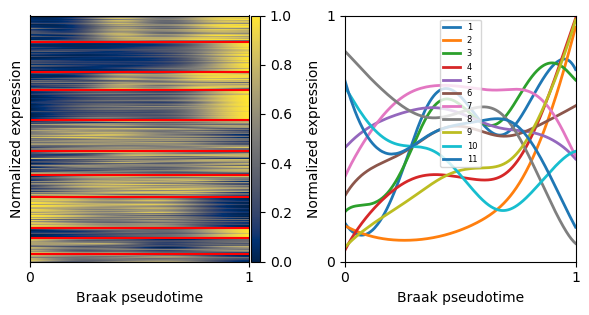

/home/masse/work/AMPPD_Trajectory/src/analysis.py:256: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  plt.tight_layout()


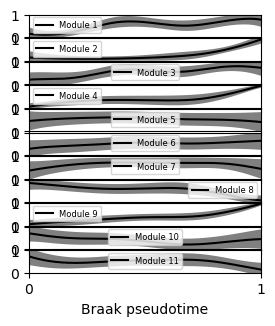

In [37]:
x_pd, y_pd, y_pd_se, clusters_pd = analysis.plot_hotspot_heatmap(
    hotspot_df, 
    gene_names_pd,
    data_pd["braak_filtered"], 
    data_pd["genes_filtered_full"], 
    clusters = np.arange(1, 12), # hotspot cluster numbers
    normalized=True,
)

In [39]:
data = {}
for m in range(1, 12):
    data[f"Module {m}"] = y_pd[m-1]

df = pd.DataFrame(data)
df.index = x_pd
df.index.name = "Normalized Pred. Braak"
df.to_csv("../hotspot_modules/pd_hotspots.csv")